In [1]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression 
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [8]:
df = pd.read_csv("dailysales.csv")
df.head()

,date,sales
0,01-Jan-18,477.0
1,02-Jan-18,365.0
2,03-Jan-18,442.0
3,04-Jan-18,490.0
4,05-Jan-18,396.0


In [10]:
df.isnull().sum()

date     0
sales    0
dtype: int64

In [11]:
df["date"]= pd.to_datetime(df["date"])

In [12]:
df= df.sort_values ("date")

In [13]:
df.head()

,date,sales
0,2018-01-01,477.0
1,2018-01-02,365.0
2,2018-01-03,442.0
3,2018-01-04,490.0
4,2018-01-05,396.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    704 non-null    datetime64[ns]
 1   sales   704 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.1 KB


In [15]:
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())
print("Number of rows:", len(df))

Start Date: 2018-01-01 00:00:00
End Date: 2019-12-31 00:00:00
Number of rows: 704


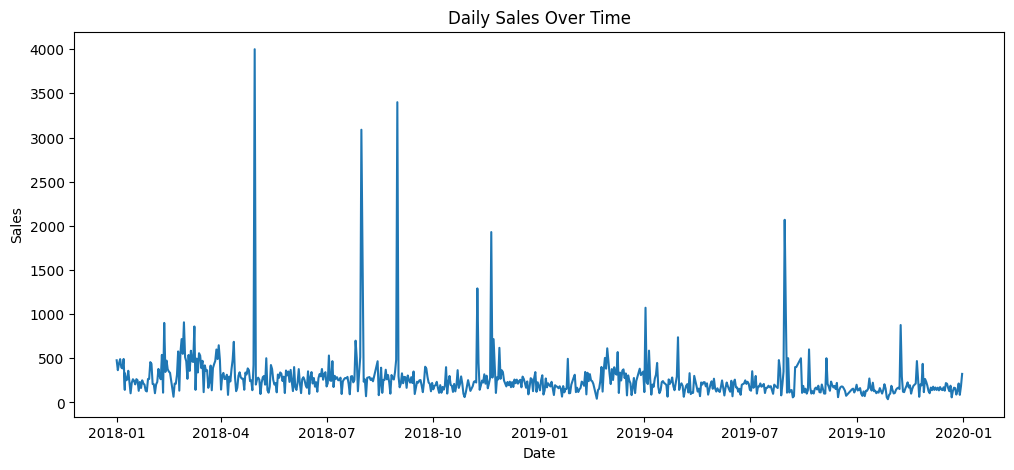

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales Over Time")
plt.show()

we are gonna extraxt some features from dataset

In [17]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

In [19]:
df["day_of_year"] = df["date"].dt.dayofyear
df["week"] = df["date"].dt.isocalendar().week.astype(int)

In [20]:
df["time_index"] = range(len(df))

In [21]:
df.head()

,date,sales,year,month,day,day_of_week,day_of_year,week,time_index
0,2018-01-01,477.0,2018,1,1,0,1,1,0
1,2018-01-02,365.0,2018,1,2,1,2,1,1
2,2018-01-03,442.0,2018,1,3,2,3,1,2
3,2018-01-04,490.0,2018,1,4,3,4,1,3
4,2018-01-05,396.0,2018,1,5,4,5,1,4


In [23]:
scaler = StandardScaler()
num_cols= [
    "year","month","day","day_of_week","day_of_year","week","time_index"
]

df[num_cols]= scaler.fit_transform(df[num_cols])

In [24]:
df.head()

,date,sales,year,month,day,day_of_week,day_of_year,week,time_index
0,2018-01-01,477.0,-0.9887,-1.592476,-1.669827,-1.509781,-1.714508,-1.681863,-1.729592
1,2018-01-02,365.0,-0.9887,-1.592476,-1.555817,-1.006283,-1.705058,-1.681863,-1.724672
2,2018-01-03,442.0,-0.9887,-1.592476,-1.441807,-0.502784,-1.695608,-1.681863,-1.719751
3,2018-01-04,490.0,-0.9887,-1.592476,-1.327796,0.000715,-1.686158,-1.681863,-1.714830
4,2018-01-05,396.0,-0.9887,-1.592476,-1.213786,0.504214,-1.676708,-1.681863,-1.709910


In [25]:
df[num_cols].std()

year           1.000711
month          1.000711
day            1.000711
day_of_week    1.000711
day_of_year    1.000711
week           1.000711
time_index     1.000711
dtype: float64

In [26]:
X = df.drop(["sales","date"],axis=1)
y =df["sales"]

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
X_train.shape , X_test.shape

((528, 7), (176, 7))

In [31]:
y_train.shape,y_test.shape

((528,), (176,))

In [33]:
model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
y_pred = model.predict(X_test)

In [64]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("RMSE:",mse)
print("R2_score:",r2)

MAE: 126.11200867476663
RMSE: 132524.02010141462
R2_score: 0.06854239558632125


In [36]:
df_arima = df[["date",'sales']].copy()
df_arima["date"] = pd.to_datetime(df_arima["date"])
df_arima = df_arima.set_index("date")
df_arima = df_arima.sort_index()

In [37]:
split = int(len(df_arima) * 0.75)

train = df_arima.iloc[:split]
test = df_arima.iloc[split:]

In [38]:
model_arima = ARIMA(
    train["sales"],
    order=(1, 1, 1)
)

arima_model = model_arima.fit()

In [39]:
arima_pred = arima_model.forecast(
    steps=len(test)
)

In [41]:
arima_mae = mean_absolute_error(test["sales"], arima_pred)

arima_rmse = np.sqrt(
    mean_squared_error(test["sales"], arima_pred)
)

arima_r2 = r2_score(test["sales"], arima_pred)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA R2:",arima_r2)

ARIMA MAE: 94.98050462045967
ARIMA RMSE: 187.37061462030096
ARIMA R2: -0.010621572398294754


In [42]:
df_prophet = df[["date", "sales"]].copy()

df_prophet.columns = ["ds", "y"]

In [43]:
split = int(len(df_prophet) * 0.75)

train_prophet = df_prophet.iloc[:split]
test_prophet = df_prophet.iloc[split:]

In [45]:
pip install prophet 

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.1 MB 7.2 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.1 MB 6.5 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.1 MB 5.6 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.1 MB 5.3 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.1 MB 5.2 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/12.1 MB 4.8 MB/s eta 0:00:02
   ------------------------- -------------- 7.6/12.1 MB 4.7 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.1 MB 4.6 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/12.1 MB 4.5 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.1 MB 4.4 MB/s eta 0:00:01
   ----------------------------------- ---- 10.7/12.1 MB 4.3 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 4.2 MB/s eta 0:00:01
   

In [47]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(train_prophet)

14:02:55 - cmdstanpy - INFO - Chain [1] start processing
14:02:57 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq="D"
)

In [50]:
forecast = prophet_model.predict(future)
prophet_pred = forecast.iloc[-len(test_prophet):]["yhat"]

In [51]:
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_pred
    )
)

prophet_r2 = r2_score(
    test_prophet["y"],
    prophet_pred
)

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)
print("Prophet R²:", prophet_r2)

Prophet MAE: 97.85071517839651
Prophet RMSE: 192.29297995775417
Prophet R²: -0.06441861486273726


In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

ts = df[["date", "sales"]].copy()

ts["date"] = pd.to_datetime(ts["date"])

ts = ts.sort_values("date")
ts = ts.set_index("date")

In [53]:
split = int(len(ts) * 0.75)

train = ts.iloc[:split]
test = ts.iloc[split:]

In [54]:
sarima_model = SARIMAX(
    train["sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

In [55]:
sarima_result = sarima_model.fit()


sarima_pred = sarima_result.forecast(steps=len(test))

In [56]:
sarima_mae = mean_absolute_error(
    test["sales"],
    sarima_pred
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test["sales"],
        sarima_pred
    )
)

sarima_r2 = r2_score(
    test["sales"],
    sarima_pred
)

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)
print("SARIMA R2:",sarima_r2)

SARIMA MAE: 83.67617474602584
SARIMA RMSE: 187.35174550872333
SARIMA R2: -0.010418033854593611


In [66]:
print("Linear Regeression ....\n", 
   "MAE:", mae,"RMSE:",mse,"R2_score:",r2_score)

print(" ......ARIMA TIME SERIES....\n",
      "ARIMA MAE:",arima_mae ,"ARIMA MSE", arima_rmse, "ARIMA R2:",arima_r2 )

print(".....PROPHET TIMES SERIES.....\n"
      "Prophet MAE:",prophet_mae,"Prophet MSE:",prophet_rmse, "Prophet R2",prophet_r2 )


print(".......SARIMA TIME SERIES.....\n"
       "SARIMA MAE:",sarima_mae, "SARIMA RMSE:", sarima_rmse, "SARIMA R2:", sarima_r2 )


Linear Regeression ....
 MAE: 126.11200867476663 RMSE: 132524.02010141462 R2_score: <function r2_score at 0x00000289168025C0>
 ......ARIMA TIME SERIES....
 ARIMA MAE: 94.98050462045967 ARIMA MSE 187.37061462030096 ARIMA R2: -0.010621572398294754
.....PROPHET TIMES SERIES.....
Prophet MAE: 97.85071517839651 Prophet MSE: 192.29297995775417 Prophet R2 -0.06441861486273726
.......SARIMA TIME SERIES.....
SARIMA MAE: 83.67617474602584 SARIMA RMSE: 187.35174550872333 SARIMA R2: -0.010418033854593611


SARIMA achieved the lowest MAE among the evaluated models, indicating that it produced the smallest average absolute forecasting error. Its advantage over ARIMA suggests that incorporating seasonal patterns improved forecasting performance. Prophet performed slightly worse than ARIMA in terms of MAE, indicating that its trend and seasonality formulation was less effective for this particular dataset. Linear Regression produced the highest MAE, suggesting that simple time-based linear relationships were insufficient to capture the underlying temporal dynamics of daily sales.

